<a href="https://colab.research.google.com/github/saisrinivasarao/Git1/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('/content/insurance.csv')

In [ ]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


In [ ]:
# summary fo data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [ ]:
#data cleaning
#null values
df.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [ ]:
df.isnull().sum().sum()

np.int64(52)

In [ ]:
# we having small number of null values so we can drop it
df.dropna(inplace=True)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
#checking duplicates
df.duplicated().sum()

np.int64(0)

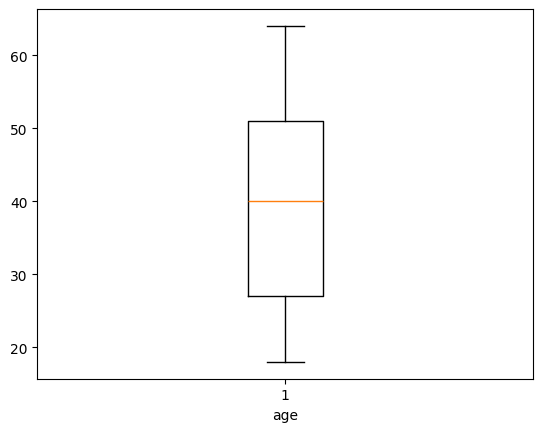

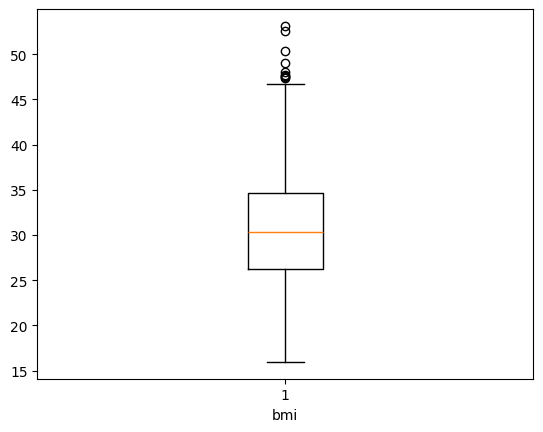

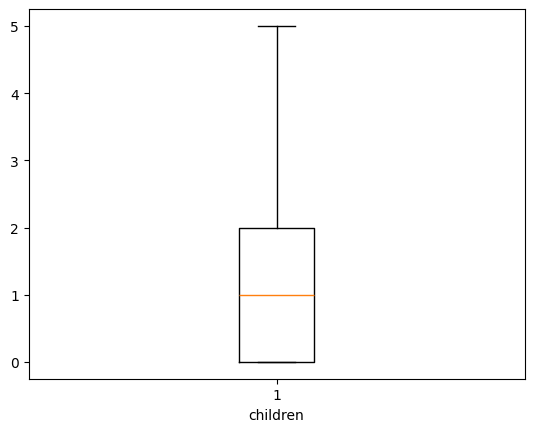

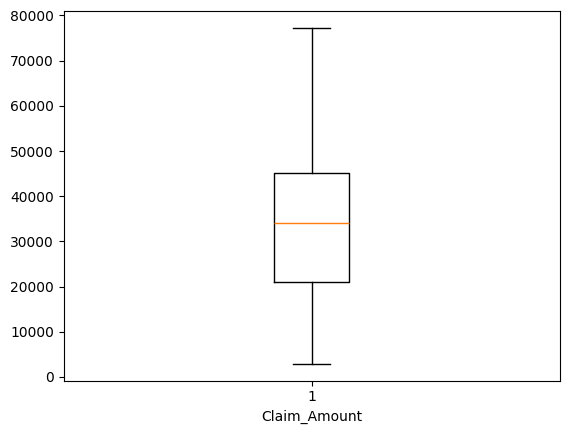

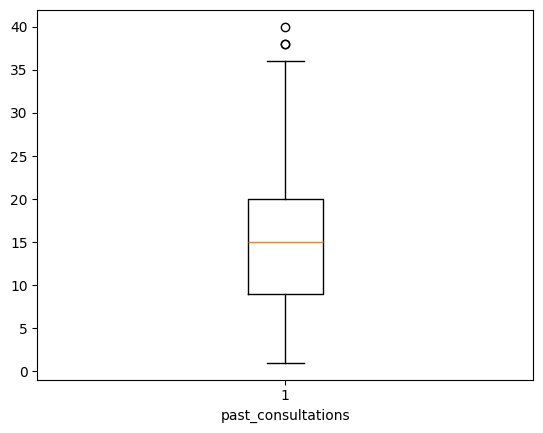

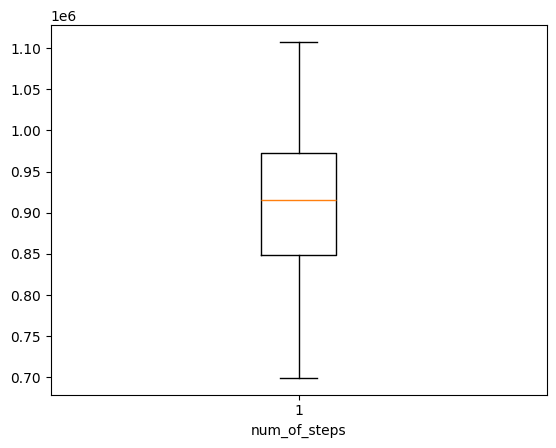

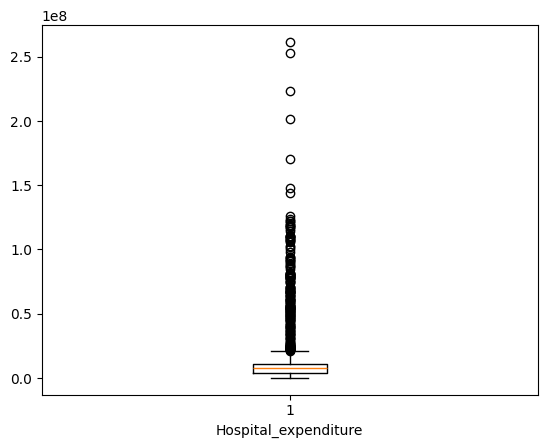

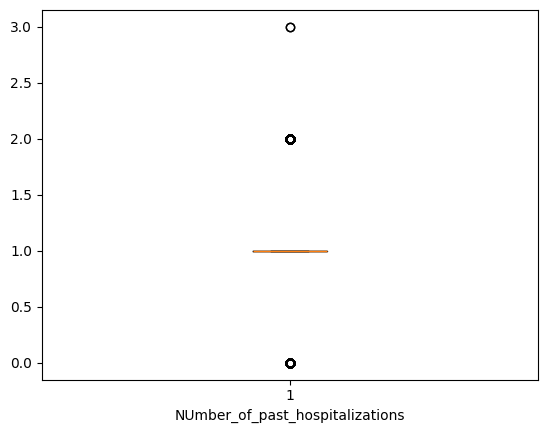

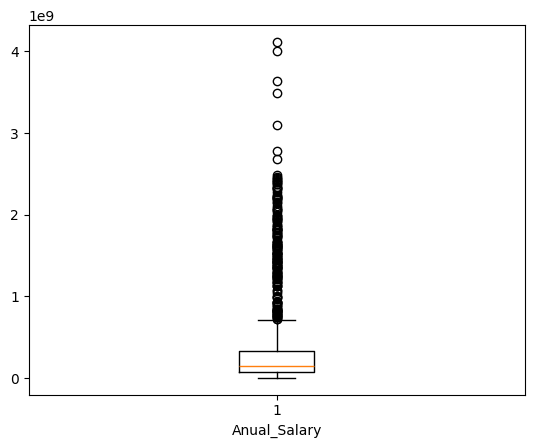

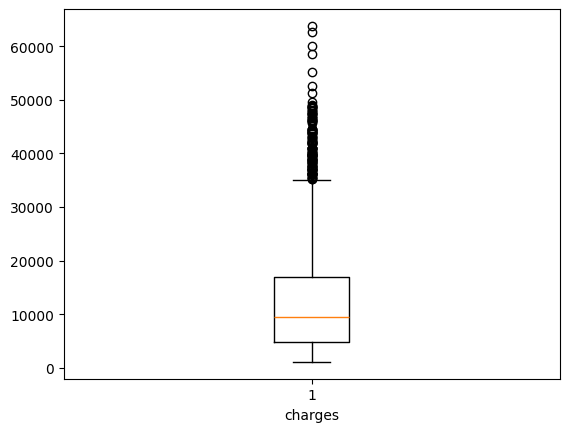

In [ ]:
#checking for outliers  in data set
for i in df.columns:
  if df[i].dtype!='object':
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [ ]:
col=['bmi','past_consultations','Hospital_expenditure','NUmber_of_past_hospitalizations','Anual_Salary']

In [ ]:
for i in col:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  IQR=q3-q1
  LB=q1-1.5*IQR
  UB=q3+1.5*IQR

  df=df[(df[i]>=LB)&(df[i]<=UB)]

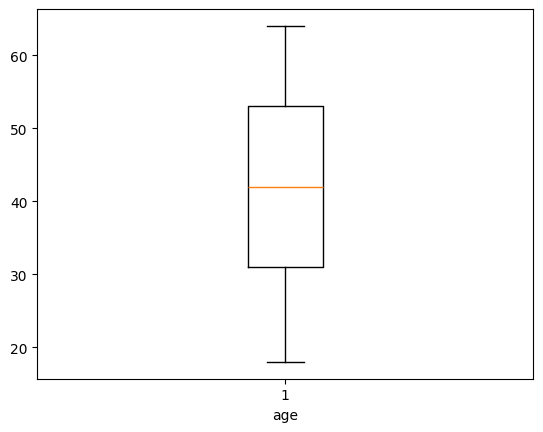

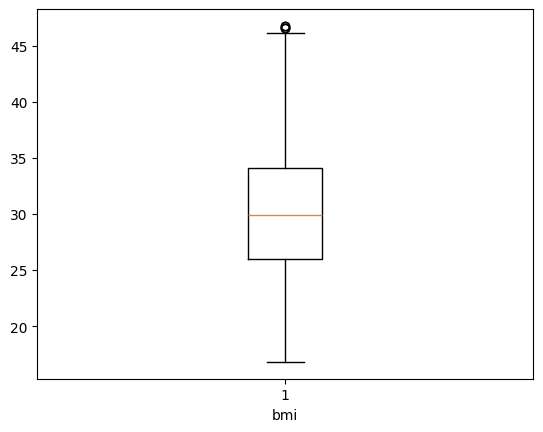

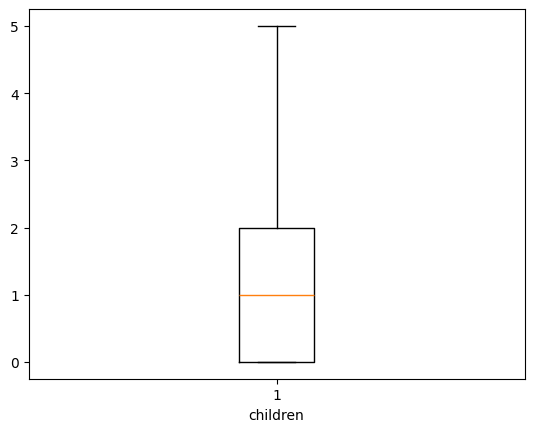

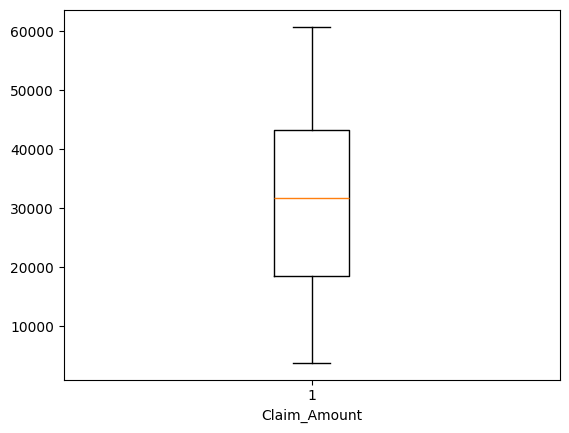

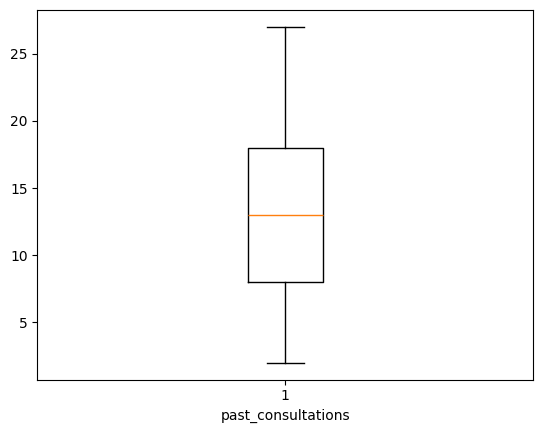

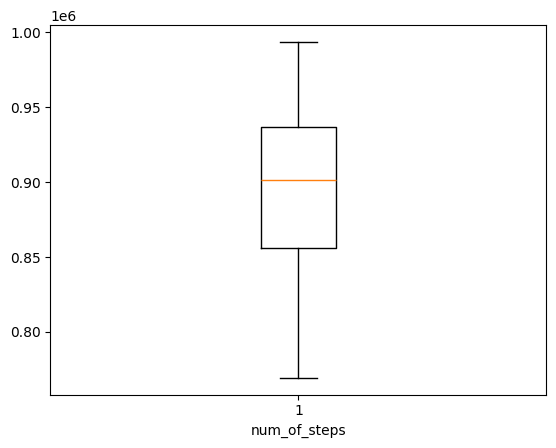

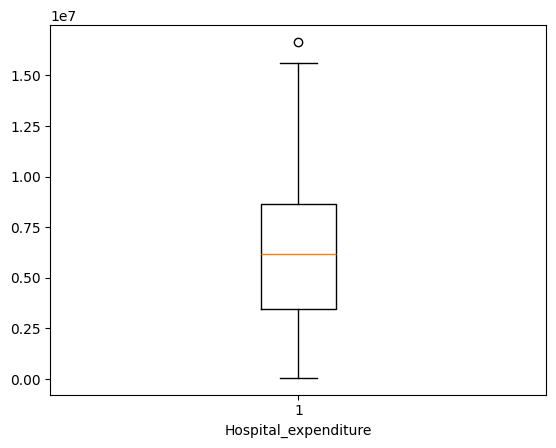

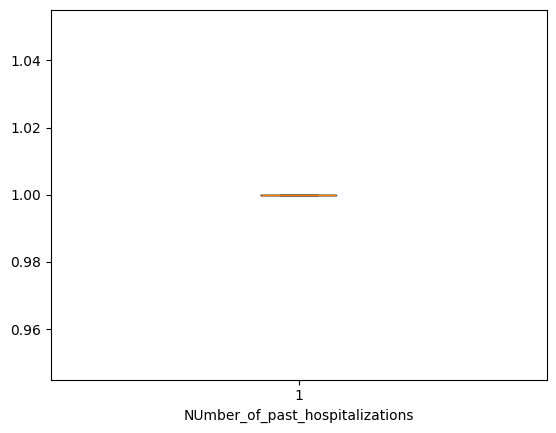

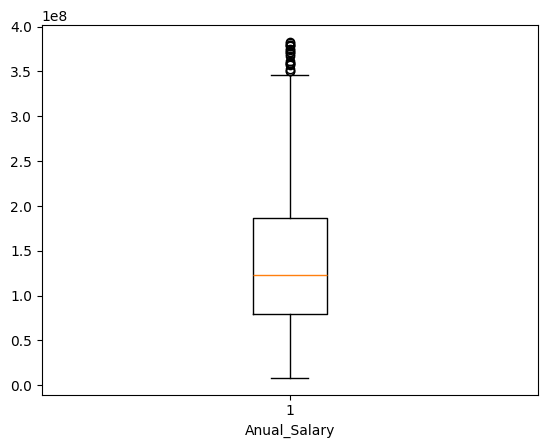

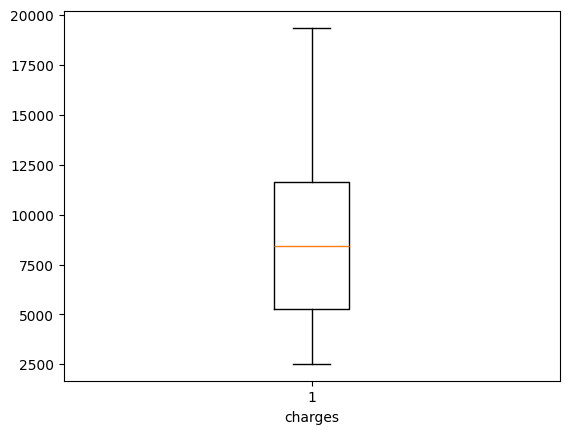

In [ ]:
#checking for outliers  in data set
for i in df.columns:
  if df[i].dtype!='object':
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

what is VIF?(varience influance factor):
it is used to remove multi colinearity

multicolinearity occurs when two or more independent columna in a dataset are highly correlated with each other

vif is used to delete multicolinear columns

if vif score<6: it means that column are good to go

if vif score is >6: it means that columns  are multi colinear columns

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# create a list all numerical columns
col_list=[]
for i in df.columns:
  if ((df[i].dtype!='object')&(i!='charges')):
     col_list.append(i)

# apply vif on columns present inside the col_list
X=df[col_list]
vif_data=pd.DataFrame()
vif_data['Column_Name']=X.columns
vif_data['VIF_Score']=[variance_inflation_factor(X.values,i)for i in range(len(X.columns))]

In [ ]:
# create a list all numerical columns
col_list=[]
for i in df.columns:
  if ((df[i].dtype!='object')&(i!='charges')):
     col_list.append(i)
col_list

['age',
 'bmi',
 'children',
 'Claim_Amount',
 'past_consultations',
 'num_of_steps',
 'Hospital_expenditure',
 'NUmber_of_past_hospitalizations',
 'Anual_Salary']

In [ ]:
# apply vif on columns present inside the col_list
X=df[col_list]
vif_data=pd.DataFrame()
vif_data['Column_Name']=X.columns
vif_data['VIF_Score']=[variance_inflation_factor(X.values,i)for i in range(len(X.columns))]

In [ ]:
vif_data

,Column_Name,VIF_Score
0,age,2.244063
1,bmi,1.050993
2,children,1.077404
3,Claim_Amount,1.040690
4,past_consultations,1.080557
5,num_of_steps,5.999974
6,Hospital_expenditure,1.182321
7,NUmber_of_past_hospitalizations,1405.296038
8,Anual_Salary,4.006099


In [ ]:
df=df.drop(['NUmber_of_past_hospitalizations'],axis=1)

In [ ]:
# create a list all numerical columns
col_list=[]
for i in df.columns:
  if ((df[i].dtype!='object')&(i!='charges')):
     col_list.append(i)

# apply vif on columns present inside the col_list
X=df[col_list]
vif_data=pd.DataFrame()
vif_data['Column_Name']=X.columns
vif_data['VIF_Score']=[variance_inflation_factor(X.values,i)for i in range(len(X.columns))]
vif_data

,Column_Name,VIF_Score
0,age,16.334839
1,bmi,26.966942
2,children,2.055611
3,Claim_Amount,5.813854
4,past_consultations,6.417597
5,num_of_steps,58.693809
6,Hospital_expenditure,5.524176
7,Anual_Salary,6.183456


In [ ]:
df=df.drop(['num_of_steps'],axis=1)

In [ ]:
# create a list all numerical columns
col_list=[]
for i in df.columns:
  if ((df[i].dtype!='object')&(i!='charges')):
     col_list.append(i)

# apply vif on columns present inside the col_list
X=df[col_list]
vif_data=pd.DataFrame()
vif_data['Column_Name']=X.columns
vif_data['VIF_Score']=[variance_inflation_factor(X.values,i)for i in range(len(X.columns))]
vif_data

,Column_Name,VIF_Score
0,age,13.463550
1,bmi,14.548677
2,children,1.945699
3,Claim_Amount,5.267436
4,past_consultations,5.911489
5,Hospital_expenditure,5.218410
6,Anual_Salary,5.990854


In [ ]:
df=df.drop(['bmi'],axis=1)

In [ ]:
# create a list all numerical columns
col_list=[]
for i in df.columns:
  if ((df[i].dtype!='object')&(i!='charges')):
     col_list.append(i)

# apply vif on columns present inside the col_list
X=df[col_list]
vif_data=pd.DataFrame()
vif_data['Column_Name']=X.columns
vif_data['VIF_Score']=[variance_inflation_factor(X.values,i)for i in range(len(X.columns))]
vif_data

,Column_Name,VIF_Score
0,age,8.739225
1,children,1.827241
2,Claim_Amount,4.846444
3,past_consultations,5.589741
4,Hospital_expenditure,4.889264
5,Anual_Salary,5.841066


In [ ]:
df=df.drop(['age'],axis=1)

In [ ]:
# create a list all numerical columns
col_list=[]
for i in df.columns:
  if ((df[i].dtype!='object')&(i!='charges')):
     col_list.append(i)

# apply vif on columns present inside the col_list
X=df[col_list]
vif_data=pd.DataFrame()
vif_data['Column_Name']=X.columns
vif_data['VIF_Score']=[variance_inflation_factor(X.values,i)for i in range(len(X.columns))]
vif_data

,Column_Name,VIF_Score
0,children,1.816913
1,Claim_Amount,4.264550
2,past_consultations,4.927842
3,Hospital_expenditure,4.672553
4,Anual_Salary,5.107190


Drop the columns until we get the vif score of all the columns into less than 6


In [ ]:
x=df.loc[:,['children','Claim_Amount','Hospital_expenditure','Anual_Salary']]
x

,children,Claim_Amount,Hospital_expenditure,Anual_Salary
151,0.0,39148.95495,8.614147e+06,5.452601e+07
152,0.0,41547.52536,2.491594e+05,1.671847e+07
153,0.0,39660.60193,3.043323e+06,4.852694e+07
154,2.0,16032.87148,1.599069e+06,2.441262e+07
155,1.0,31090.98977,3.015365e+06,5.853579e+07
...,...,...,...,...
1036,2.0,44184.65414,1.473451e+07,3.687871e+08
1041,0.0,27184.27803,1.266673e+07,3.743228e+08
1046,1.0,51168.25474,1.665982e+07,3.712188e+08
1048,3.0,46619.40230,1.361938e+07,3.812895e+08


In [ ]:
y=df.loc[:,['charges']]
y

,charges
151,2523.16950
152,2527.81865
153,2534.39375
154,2566.47070
155,2585.26900
...,...
1036,18767.73770
1041,18955.22017
1046,19107.77960
1048,19199.94400


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=0)

In [ ]:
x_train

,children,Claim_Amount,Hospital_expenditure,Anual_Salary
627,0.0,49140.254220,4.776407e+06,9.172299e+07
798,0.0,30327.460710,5.463856e+06,1.526574e+08
275,1.0,4823.280889,7.876634e+06,1.066657e+08
765,1.0,51596.963330,4.467269e+06,2.073807e+08
322,0.0,38687.192780,4.915476e+05,1.183499e+08
...,...,...,...,...
1018,1.0,53840.228250,7.081732e+06,3.390847e+08
354,2.0,30738.302180,5.903368e+06,1.167998e+08
809,1.0,43711.972380,5.577876e+06,2.143823e+08
737,1.0,54194.471650,6.366762e+06,1.438831e+08


In [ ]:
x_test

,children,Claim_Amount,Hospital_expenditure,Anual_Salary
848,1.0,43993.29455,4.924636e+06,2.175766e+08
504,0.0,28351.15966,2.316930e+06,5.268511e+07
719,3.0,44544.86046,1.010412e+07,1.451976e+08
1024,4.0,23327.30277,8.800807e+06,3.333838e+08
860,0.0,27369.02461,3.634140e+06,1.877743e+08
...,...,...,...,...
311,3.0,43210.04994,9.862763e+05,2.162081e+07
895,2.0,12770.13249,4.895703e+06,2.081729e+08
799,0.0,33893.25137,1.048993e+07,1.554098e+08
201,0.0,19040.96490,2.561631e+06,2.200409e+07


In [ ]:
y_train

,charges
627,8688.85885
798,11363.28320
275,4076.49700
765,10942.13205
322,4571.41305
...,...
1018,17626.23951
354,4922.91590
809,11512.40500
737,10436.09600


Model Building

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()# give a name to a model

In [ ]:
# training the model
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
#test the model
y_pred=model.predict(x_test)

In [ ]:
y_pred#model answers

array([[12210.88621723],
       [ 4483.32667767],
       [ 9304.07779874],
       [17358.6978591 ],
       [10543.73168835],
       [10879.82840839],
       [ 5989.23377021],
       [12581.85799898],
       [19604.65126936],
       [ 4913.21615342],
       [19038.4113836 ],
       [ 6732.54394082],
       [11611.56426714],
       [ 9348.15801741],
       [11511.19967436],
       [15260.83106922],
       [15573.60021774],
       [ 8222.76274425],
       [ 7810.67865817],
       [13956.47254308],
       [ 9145.22013663],
       [ 8729.37346344],
       [12328.59516243],
       [ 5022.01984991],
       [11069.91163412],
       [ 8685.6561657 ],
       [ 5683.96679248],
       [ 3998.41190592],
       [ 6783.698395  ],
       [ 9131.50888036],
       [ 5578.67289882],
       [11033.16164296],
       [10075.58419216],
       [ 8744.48941377],
       [ 4711.25853765],
       [ 4385.20778781],
       [ 3249.58146022],
       [ 7239.16962818],
       [ 2883.0465174 ],
       [ 8963.68202169],


In [ ]:
#now we have to compare it
new_df=pd.DataFrame()
new_df['Actual_charges']=y_test
new_df['Predicted_charges']=y_pred
new_df

,Actual_charges,Predicted_charges
848,12044.34200,12210.886217
504,7050.02130,4483.326678
719,10115.00885,9304.077799
1024,17942.10600,17358.697859
860,12235.83920,10543.731688
...,...,...
311,4466.62140,3378.758380
895,12925.88600,11375.248344
799,11365.95200,9499.689703
201,3172.01800,2991.718127


In [ ]:
# i will ivaluate the model performance by r2 score
from sklearn.metrics import r2_score


In [ ]:
r2_score(y_test,y_pred)*100

84.06103113615411

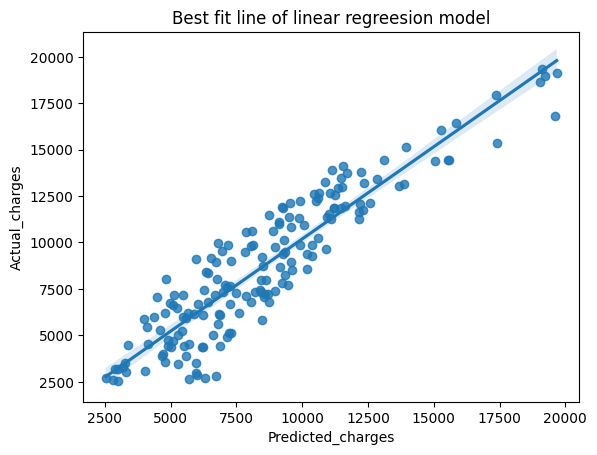

In [ ]:
sns.regplot(x=y_pred,y=y_test)
plt.xlabel('Predicted_charges')
plt.ylabel('Actual_charges')
plt.title('Best fit line of linear regreesion model')
plt.show()